<a href="https://colab.research.google.com/github/davidrpugh/introduction-to-deep-learning/blob/master/notebooks/03d-learning-rate-schedulers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import model_selection, preprocessing, pipeline
import torch
from torch import nn, optim, utils

In [2]:
def clip_gradients_(
    clip_grad_strategy,
    model_fn,
    clip_value=None,
    error_if_nonfinite=False,
    max_norm=None,
    norm_type=2.0):
    if clip_grad_strategy == "value" and clip_value is not None:
        nn.utils.clip_grad_value_(
            model_fn.parameters(),
            clip_value
        )
    elif clip_grad_strategy == "norm" and max_norm is not None:
        nn.utils.clip_grad_norm_(
            model_fn.parameters(),
            max_norm,
            norm_type,
            error_if_nonfinite
        )
    elif clip_grad_strategy is None:
        pass
    else:
        raise NotImplementedError()


def compute_average_loss(dataloader, loss_fn, model_fn):
    total_loss = torch.zeros(1, 1)
    for features, targets in dataloader:
        predictions = model_fn(features)
        total_loss += loss_fn(predictions, targets)
    average_loss = total_loss / len(dataloader)
    return average_loss


def initialize_linear_layer(
    in_features,
    out_features,
    init_strategy_=nn.init.kaiming_uniform_):
    linear_layer = nn.Linear(in_features, out_features)
    init_strategy_(linear_layer.weight)
    return linear_layer


def make_mlp_classifier(
    input_size,
    hidden_sizes=None,
    output_size=2,
    activation_fn=None,
    init_strategy_=nn.init.kaiming_uniform_,
    batch_normalization=False):
    modules = []
    hidden_sizes = [] if hidden_sizes is None else hidden_sizes
    for hidden_size in hidden_sizes:
        hidden_layer = initialize_linear_layer(
            input_size,
            hidden_size,
            init_strategy_,
        )
        modules.append(hidden_layer)
        if batch_normalization:
            modules.append(nn.BatchNorm1d(hidden_size))
        if activation_fn is not None:
            modules.append(activation_fn)
        input_size=hidden_size
    output_layer = initialize_linear_layer(
            input_size,
            output_size,
            init_strategy_,
    )
    modules.append(output_layer)
    modules.append(nn.LogSoftmax(dim=1))
    model_fn = nn.Sequential(*modules)
    return model_fn, nn.NLLLoss()


## Define the training loop

In [3]:
def fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    clip_grad_strategy=None,
    clip_value=None,
    error_if_nonfinite=False,
    lr_scheduler=None,
    log_epochs=1,
    max_epochs=1,
    max_norm=None,
    norm_type=2.0):

    history = {
        "epoch": [],
        "average_train_loss": [],
        "average_val_loss": [],
        "lr": [],
    }

    for epoch in range(max_epochs):
        total_train_loss = torch.zeros(1, 1)
        model_fn = model_fn.train()
        for features, targets in train_dataloader:

            # forward pass
            predictions = model_fn(features)
            loss = loss_fn(predictions, targets)
            total_train_loss += loss

            # backward pass
            loss.backward()
            clip_gradients_(
                clip_grad_strategy,
                model_fn,
                clip_value,
                error_if_nonfinite,
                max_norm,
                norm_type
            )
            optimizer.step()
            optimizer.zero_grad()

        average_train_loss = total_train_loss / len(train_dataloader)
        history["epoch"].append(epoch)
        history["average_train_loss"].append(average_train_loss.item())

        # validation after every training epoch
        model_fn = model_fn.eval()
        with torch.inference_mode():
            average_val_loss = compute_average_loss(
                val_dataloader,
                loss_fn,
                model_fn
            )
        history["average_val_loss"].append(average_val_loss.item())

        # update the learning rate after every training epoch
        if lr_scheduler is not None:
            history["lr"].append(lr_scheduler.get_last_lr()[-1])
            lr_scheduler.step()

        if epoch % log_epochs == 0:
            message = f"Epoch {epoch}, Average train Loss {average_train_loss.item():.4f}, Average val Loss {average_val_loss.item():.4f}"
            print(message)

    history_df = (pd.DataFrame.from_dict(history)
                              .set_index("epoch"))
    return history_df


## Load the data

In [4]:
INPUT_SIZE = 784
OUTPUT_SIZE = 10

_train_data = pd.read_csv(
    "./sample_data/mnist_train_small.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)
train_data, val_data = model_selection.train_test_split(
    _train_data,
    test_size=0.1,
    stratify=_train_data.loc[:, "label"]
)

test_data = pd.read_csv(
    "./sample_data/mnist_test.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)


In [5]:
features_preprocessor = pipeline.make_pipeline(
    preprocessing.MinMaxScaler(),
    preprocessing.FunctionTransformer(lambda arr: arr.astype(np.float32)),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)

target_preprocessor = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(lambda df: df.to_numpy()),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)


In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 2

# create the training dataset and dataloader
train_features_tensor = features_preprocessor.fit_transform(
    train_data.drop("label", axis=1)
)

train_target_tensor = target_preprocessor.fit_transform(
    train_data.loc[:, "label"]
)

train_dataset = utils.data.TensorDataset(
    train_features_tensor,
    train_target_tensor
)

train_dataloader = utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the validation dataset and dataloader
val_features_tensor = features_preprocessor.transform(
    val_data.drop("label", axis=1)
)

val_target_tensor = target_preprocessor.transform(
    val_data.loc[:, "label"]
)

val_dataset = utils.data.TensorDataset(
    val_features_tensor,
    val_target_tensor
)

val_dataloader = utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the test dataset and dataloader
test_features_tensor = features_preprocessor.transform(
    test_data.drop("label", axis=1)
)

test_target_tensor = target_preprocessor.transform(
    test_data.loc[:, "label"]
)

test_dataset = utils.data.TensorDataset(
    test_features_tensor,
    test_target_tensor
)

test_dataloader = utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)


# Learning Rate Schedulers

In [ ]:
optim.lr_scheduler.

## Power Scheduling

In [ ]:
optim.lr_scheduler.PolynomialLR?

In [7]:
HIDDEN_SIZE = 100
LEARNING_RATE = 1e-1
MAX_EPOCHS = 20

model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE
)
lr_scheduler = optim.lr_scheduler.PolynomialLR(
    optimizer,
    total_iters=5,
    power=1.0
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.4724, Average val Loss 0.4527
Epoch 1, Average train Loss 0.2530, Average val Loss 0.2781
Epoch 2, Average train Loss 0.1945, Average val Loss 0.2302
Epoch 3, Average train Loss 0.1610, Average val Loss 0.2077
Epoch 4, Average train Loss 0.1409, Average val Loss 0.1972
Epoch 5, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 6, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 7, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 8, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 9, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 10, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 11, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 12, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 13, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 14, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 15, Average train Loss 0.1305, Average val Loss 0.1972
Epoch 16, Average train Loss 0.130

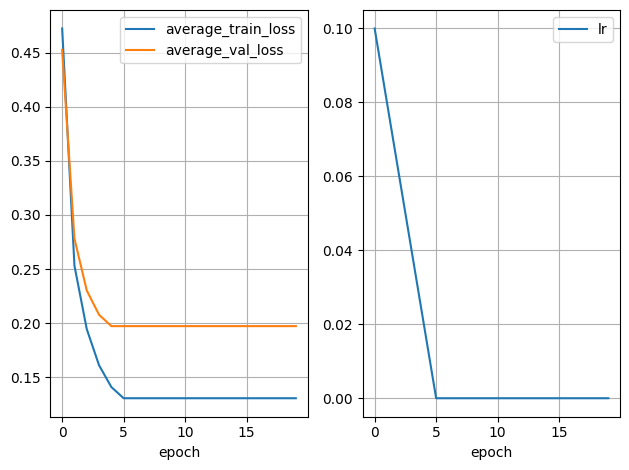

In [12]:
fig, axes = plt.subplots(1, 2)
_ = (
    history.loc[:, ["average_train_loss", "average_val_loss"]]
           .plot(ax=axes[0], grid=True)
)
_ = (
    history.loc[:, ["lr"]]
           .plot(ax=axes[1], grid=True)
)
fig.tight_layout()

## Exponential Scheduling

In [ ]:
optim.lr_scheduler.ExponentialLR?

In [13]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE
)
lr_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.9
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)


Epoch 0, Average train Loss 0.4665, Average val Loss 0.4666
Epoch 1, Average train Loss 0.2607, Average val Loss 0.2893
Epoch 2, Average train Loss 0.1992, Average val Loss 0.2394
Epoch 3, Average train Loss 0.1615, Average val Loss 0.2107
Epoch 4, Average train Loss 0.1355, Average val Loss 0.1925
Epoch 5, Average train Loss 0.1166, Average val Loss 0.1774
Epoch 6, Average train Loss 0.1018, Average val Loss 0.1664
Epoch 7, Average train Loss 0.0900, Average val Loss 0.1589
Epoch 8, Average train Loss 0.0803, Average val Loss 0.1520
Epoch 9, Average train Loss 0.0725, Average val Loss 0.1471
Epoch 10, Average train Loss 0.0660, Average val Loss 0.1435
Epoch 11, Average train Loss 0.0605, Average val Loss 0.1408
Epoch 12, Average train Loss 0.0559, Average val Loss 0.1384
Epoch 13, Average train Loss 0.0521, Average val Loss 0.1368
Epoch 14, Average train Loss 0.0489, Average val Loss 0.1355
Epoch 15, Average train Loss 0.0461, Average val Loss 0.1346
Epoch 16, Average train Loss 0.043

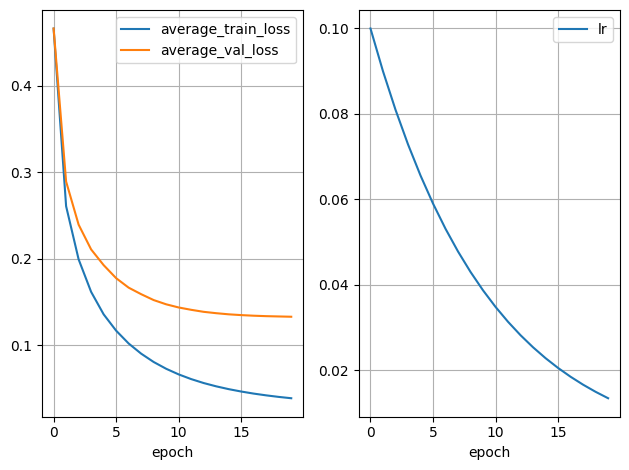

In [14]:
fig, axes = plt.subplots(1, 2)
_ = (
    history.loc[:, ["average_train_loss", "average_val_loss"]]
            .plot(ax=axes[0], grid=True)
)
_ = (
    history.loc[:, ["lr"]]
           .plot(ax=axes[1], grid=True)
)
fig.tight_layout()

## Step-wise Constant Scheduling

In [ ]:
optim.lr_scheduler.StepLR?

In [15]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE
)

lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)


Epoch 0, Average train Loss 0.4637, Average val Loss 0.4553
Epoch 1, Average train Loss 0.2597, Average val Loss 0.3219
Epoch 2, Average train Loss 0.1948, Average val Loss 0.2925
Epoch 3, Average train Loss 0.1572, Average val Loss 0.2562
Epoch 4, Average train Loss 0.1304, Average val Loss 0.2196
Epoch 5, Average train Loss 0.0937, Average val Loss 0.1576
Epoch 6, Average train Loss 0.0872, Average val Loss 0.1537
Epoch 7, Average train Loss 0.0841, Average val Loss 0.1514
Epoch 8, Average train Loss 0.0816, Average val Loss 0.1498
Epoch 9, Average train Loss 0.0795, Average val Loss 0.1483
Epoch 10, Average train Loss 0.0761, Average val Loss 0.1475
Epoch 11, Average train Loss 0.0756, Average val Loss 0.1472
Epoch 12, Average train Loss 0.0753, Average val Loss 0.1470
Epoch 13, Average train Loss 0.0750, Average val Loss 0.1468
Epoch 14, Average train Loss 0.0748, Average val Loss 0.1466
Epoch 15, Average train Loss 0.0744, Average val Loss 0.1466
Epoch 16, Average train Loss 0.074

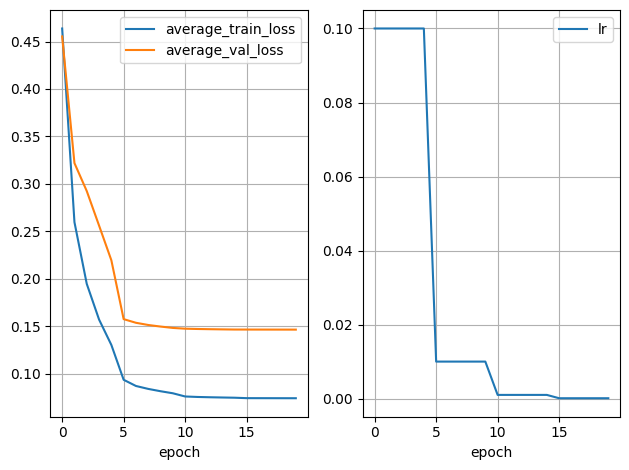

In [16]:
fig, axes = plt.subplots(1, 2)
_ = (
    history.loc[:, ["average_train_loss", "average_val_loss"]]
           .plot(ax=axes[0], grid=True)
)
_ = (
    history.loc[:, ["lr"]]
           .plot(ax=axes[1], grid=True)
)
fig.tight_layout()

## 1-cycle Scheduling

In [ ]:
optim.lr_scheduler.OneCycleLR?

In [17]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE / 10
)

lr_scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    epochs=MAX_EPOCHS,
    steps_per_epoch=1, # because we update after each epoch!
    max_lr=LEARNING_RATE,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)


Epoch 0, Average train Loss 0.4999, Average val Loss 0.3229
Epoch 1, Average train Loss 0.3009, Average val Loss 0.2646
Epoch 2, Average train Loss 0.3101, Average val Loss 0.2803
Epoch 3, Average train Loss 0.3359, Average val Loss 0.3625
Epoch 4, Average train Loss 0.3578, Average val Loss 0.5588
Epoch 5, Average train Loss 0.3976, Average val Loss 0.4110
Epoch 6, Average train Loss 0.4592, Average val Loss 0.4724
Epoch 7, Average train Loss 0.4195, Average val Loss 0.3967
Epoch 8, Average train Loss 0.4065, Average val Loss 0.6440
Epoch 9, Average train Loss 0.5256, Average val Loss 0.4092
Epoch 10, Average train Loss 0.2757, Average val Loss 0.3936
Epoch 11, Average train Loss 0.1908, Average val Loss 0.3792
Epoch 12, Average train Loss 0.1529, Average val Loss 0.4836
Epoch 13, Average train Loss 0.1152, Average val Loss 0.3446
Epoch 14, Average train Loss 0.0584, Average val Loss 0.2819
Epoch 15, Average train Loss 0.0320, Average val Loss 0.2734
Epoch 16, Average train Loss 0.013

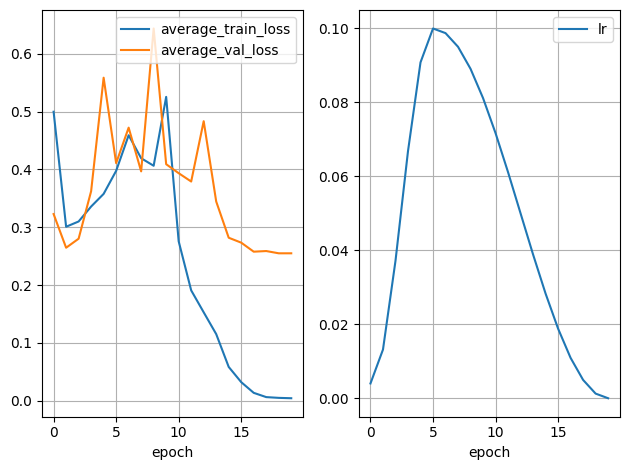

In [18]:
fig, axes = plt.subplots(1, 2)
_ = (
    history.loc[:, ["average_train_loss", "average_val_loss"]]
           .plot(ax=axes[0], grid=True)
)
_ = (
    history.loc[:, ["lr"]]
           .plot(ax=axes[1], grid=True)
)
fig.tight_layout()

## Performance Scheduling

In [ ]:
optim.lr_scheduler.ReduceLROnPlateau?

In [19]:
def fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    clip_grad_strategy=None,
    clip_value=None,
    error_if_nonfinite=False,
    lr_scheduler=None,
    log_epochs=1,
    max_epochs=1,
    max_norm=None,
    norm_type=2.0):

    history = {
        "epoch": [],
        "average_train_loss": [],
        "average_val_loss": [],
        "lr": [],
    }

    for epoch in range(max_epochs):
        total_train_loss = torch.zeros(1, 1)
        model_fn = model_fn.train()
        for features, targets in train_dataloader:

            # forward pass
            predictions = model_fn(features)
            loss = loss_fn(predictions, targets)
            total_train_loss += loss

            # backward pass
            loss.backward()
            clip_gradients_(
                clip_grad_strategy,
                model_fn,
                clip_value,
                error_if_nonfinite,
                max_norm,
                norm_type
            )
            optimizer.step()
            optimizer.zero_grad()

        average_train_loss = total_train_loss / len(train_dataloader)
        history["epoch"].append(epoch)
        history["average_train_loss"].append(average_train_loss.item())

        # validation after every training epoch
        model_fn = model_fn.eval()
        with torch.inference_mode():
            average_val_loss = compute_average_loss(
                val_dataloader,
                loss_fn,
                model_fn
            )
        history["average_val_loss"].append(average_val_loss.item())

        # update the learning rate after every training epoch
        if lr_scheduler is not None:
            lr_scheduler.step(average_val_loss.item())
            history["lr"].append(lr_scheduler._last_lr[-1])

        if epoch % log_epochs == 0:
            message = f"Epoch {epoch}, Average train Loss {average_train_loss.item():.4f}, Average val Loss {average_val_loss.item():.4f}"
            print(message)

    history_df = (pd.DataFrame.from_dict(history)
                              .set_index("epoch"))
    return history_df


In [20]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE
)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)


Epoch 0, Average train Loss 0.4616, Average val Loss 0.4649
Epoch 1, Average train Loss 0.2650, Average val Loss 0.3365
Epoch 2, Average train Loss 0.2004, Average val Loss 0.2634
Epoch 3, Average train Loss 0.1595, Average val Loss 0.2221
Epoch 4, Average train Loss 0.1310, Average val Loss 0.1996
Epoch 5, Average train Loss 0.1095, Average val Loss 0.1838
Epoch 6, Average train Loss 0.0929, Average val Loss 0.1729
Epoch 7, Average train Loss 0.0792, Average val Loss 0.1660
Epoch 8, Average train Loss 0.0674, Average val Loss 0.1624
Epoch 9, Average train Loss 0.0570, Average val Loss 0.1583
Epoch 10, Average train Loss 0.0482, Average val Loss 0.1563
Epoch 11, Average train Loss 0.0400, Average val Loss 0.1546
Epoch 12, Average train Loss 0.0329, Average val Loss 0.1537
Epoch 13, Average train Loss 0.0268, Average val Loss 0.1533
Epoch 14, Average train Loss 0.0217, Average val Loss 0.1533
Epoch 15, Average train Loss 0.0175, Average val Loss 0.1536
Epoch 16, Average train Loss 0.013

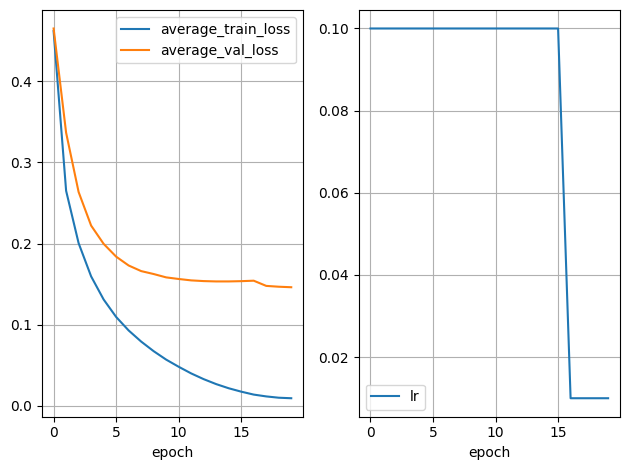

In [21]:
fig, axes = plt.subplots(1, 2)
_ = (
    history.loc[:, ["average_train_loss", "average_val_loss"]]
           .plot(ax=axes[0], grid=True)
)
_ = (
    history.loc[:, ["lr"]]
           .plot(ax=axes[1], grid=True)
)
fig.tight_layout()

## Exercise:

Create a MLP with three hidden layers, each with 100 neurons per layer, and train it for 10 epochs using the Adam optimizer with the following learning rate schedulers.

1. ExponentialLR
2. ReduceLROnPlateau
3. OneCycleLR

Plot the learning rate schedule, as well as the training and validation loss curves. Compare and contrast.